**Lab 1 : HAR using WISDM datadet using CNN model.**

In [ ]:
import pandas as pd

columns = ['user','activity','timestamp','x','y','z']

data = pd.read_csv(
    '/content/WISDM_ar_v1.1_raw.txt',
    header=None,
    names=columns,
    sep=',',
    engine='python',
    on_bad_lines='skip'
)

print("Loaded data shape:", data.shape)
data.head()

Loaded data shape: (1086466, 6)


,user,activity,timestamp,x,y,z
0,33,Jogging,49105962326000,-0.694638,12.680544,0.50395286;
1,33,Jogging,49106062271000,5.012288,11.264028,0.95342433;
2,33,Jogging,49106112167000,4.903325,10.882658,-0.08172209;
3,33,Jogging,49106222305000,-0.612916,18.496431,3.0237172;
4,33,Jogging,49106332290000,-1.184970,12.108489,7.205164;


In [ ]:
data['z'] = data['z'].astype(str).str.replace(';','', regex=False)

data[['x','y','z']] = data[['x','y','z']].astype(float)
data.dropna(inplace=True)
activities = ['Walking','Jogging','Upstairs','Downstairs','Sitting','Standing']
data = data[data['activity'].isin(activities)]

print(data['activity'].value_counts())


activity
Walking       418393
Jogging       336445
Upstairs      122869
Downstairs    100425
Sitting        59939
Standing       48394
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['activity_encoded'] = le.fit_transform(data['activity'])

print(dict(zip(le.classes_, le.transform(le.classes_))))


{'Downstairs': np.int64(0), 'Jogging': np.int64(1), 'Sitting': np.int64(2), 'Standing': np.int64(3), 'Upstairs': np.int64(4), 'Walking': np.int64(5)}


In [ ]:
import numpy as np
def sliding_window(data, window_size=200, step_size=100):
    X, y = [], []
    for i in range(0, len(data) - window_size, step_size):
        window = data.iloc[i:i+window_size]
        X.append(window[['x','y','z']].values)
        y.append(window['activity_encoded'].mode()[0])
    return np.array(X), np.array(y)

X, y = sliding_window(data)

print("Input shape:", X.shape)
print("Labels shape:", y.shape)


Input shape: (10863, 200, 3)
Labels shape: (10863,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, Flatten

model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(X.shape[1], 3)),
    MaxPooling1D(2),

    Conv1D(128, kernel_size=3, activation='relu'),
    MaxPooling1D(2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 198, 64)        │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 99, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 97, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6144)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       786,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 812,678 (3.10 MB)

 Trainable params: 812,678 (3.10 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import time
start_time = time.time()
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2
)

end_time = time.time()
training_time = end_time - start_time

Epoch 1/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 13s 70ms/step - accuracy: 0.5943 - loss: 1.6630 - val_accuracy: 0.8349 - val_loss: 0.4800
Epoch 2/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - accuracy: 0.8179 - loss: 0.4876 - val_accuracy: 0.8907 - val_loss: 0.2991
Epoch 3/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.8801 - loss: 0.3387 - val_accuracy: 0.9143 - val_loss: 0.2259
Epoch 4/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - accuracy: 0.9146 - loss: 0.2542 - val_accuracy: 0.9281 - val_loss: 0.2059
Epoch 5/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.9439 - loss: 0.1809 - val_accuracy: 0.9453 - val_loss: 0.1583
Epoch 6/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - accuracy: 0.9492 - loss: 0.1514 - val_accuracy: 0.9528 - val_loss: 0.1337
Epoch 7/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - accuracy: 0.9636 - loss: 0.1121 - val_accuracy: 0.9534 - val_loss: 0.1244
Epoch 8/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.9689 - loss: 0.1014 - val_a

In [ ]:
print("Training Time on GPU :", training_time)

Training Time on GPU : 112.00541114807129


68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Test Accuracy: 96.31845355033875 %


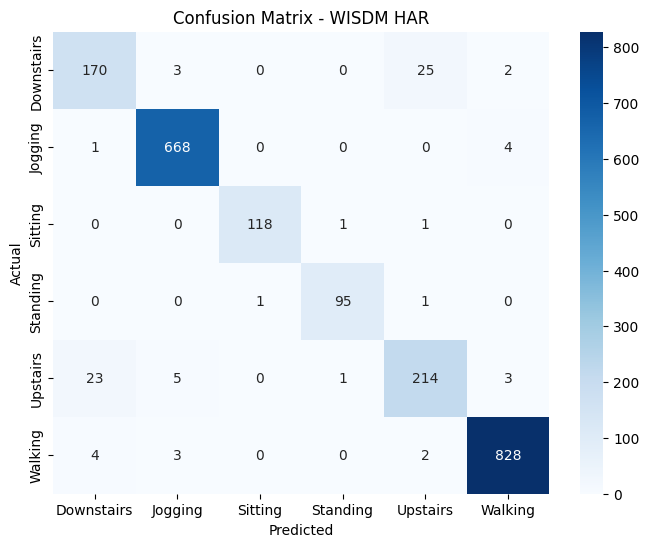

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = np.argmax(model.predict(X_test), axis=1)
cm = confusion_matrix(y_test, y_pred)

loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print("Test Accuracy:", accuracy * 100, "%")

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - WISDM HAR')
plt.show()